In [317]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def get_score(X, y, label=''):
    lr = LogisticRegression(max_iter=1000, random_state=42)
    acc = cross_val_score(lr, X, y, cv=CV, scoring='accuracy').mean()
    print(f'{label} \naccuracy = {acc:.4f}\n')
    return acc

y = train['Survived']

## Baseline

In [301]:
X_base = train[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].fillna(-1)
baseline = score(X_base, y, 'Baseline (числовые, пропуски=-1)')
scores = {'baseline': baseline}

Baseline (числовые, пропуски=-1) 
accuracy = 0.6970



## Age missing values

In [302]:
def prepare_base(df_train, df_test, age_strategy):
    train_msvl = df_train.copy()
    test_msvl  = df_test.copy()

    if age_strategy == 'median':
        median_age = train_msvl['Age'].median()
        train_msvl['Age'] = train_msvl['Age'].fillna(median_age)
        test_msvl['Age']  = test_msvl['Age'].fillna(median_age)

    elif age_strategy == 'median_group':
        # Медиана по группе Pclass+Sex
        group_median = train_msvl.groupby(['Pclass', 'Sex'])['Age'].median()
        def fill_age(row):
            if pd.isna(row['Age']):
                return group_median[row['Pclass'], row['Sex']]
            return row['Age']
        train_msvl['Age'] = train_msvl.apply(fill_age, axis=1)
        test_msvl['Age']  = test_msvl.apply(fill_age, axis=1)

    elif age_strategy == 'minus1':
        train_msvl['Age'] = train_msvl['Age'].fillna(-1)
        test_msvl['Age']  = test_msvl['Age'].fillna(-1)

    elif age_strategy == 'zero_filling':
        train_msvl['Age'] = train_msvl['Age'].fillna(0)
        test_msvl['Age']  = test_msvl['Age'].fillna(0)
    
    elif age_strategy == 'age_band':
        train_msvl['Age_band'] = 0
        train_msvl.loc[train_msvl['Age'] <= 16,'Age_band'] = 0
        train_msvl.loc[(train_msvl['Age'] > 16) & (train_msvl['Age'] <= 32),'Age_band'] = 1
        train_msvl.loc[(train_msvl['Age'] > 32) & (train_msvl['Age'] <= 48),'Age_band'] = 2
        train_msvl.loc[(train_msvl['Age'] > 48) & (train_msvl['Age'] <= 64),'Age_band'] = 3
        train_msvl.loc[train_msvl['Age'] > 64,'Age_band'] = 4

    # Embarked: 2 пропуска → мода
    embarked_mode = train_msvl['Embarked'].mode()[0]
    train_msvl['Embarked'] = train_msvl['Embarked'].fillna(embarked_mode)
    test_msvl['Embarked']  = test_msvl['Embarked'].fillna(embarked_mode)

    # Fare: 1 пропуск в test → медиана по классу
    fare_medians = train_msvl.groupby('Pclass')['Fare'].median()
    for df in [train_msvl, test_msvl]:
        mask_zero = df['Fare'] == 0
        df.loc[mask_zero, 'Fare'] = df.loc[mask_zero, 'Pclass'].map(fare_medians)

        mask_nan = df['Fare'].isna()
        if mask_nan.any():
            df.loc[mask_nan, 'Fare'] = df.loc[mask_nan, 'Pclass'].map(fare_medians)
    return train_msvl, test_msvl

for strategy in ['minus1', 'median', 'median_group', 'zero_filling', 'age_band']:
    tr, _ = prepare_base(train, test, age_strategy=strategy)
    if strategy != 'age_band':
        X = tr[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
    else:
        X = tr[['Pclass', 'Age_band', 'SibSp', 'Parch', 'Fare']]
    get_score(X, y, f'{strategy}')

minus1 
accuracy = 0.6970

median 
accuracy = 0.6947

median_group 
accuracy = 0.6970

zero_filling 
accuracy = 0.6959

age_band 
accuracy = 0.6914



             nulls
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0


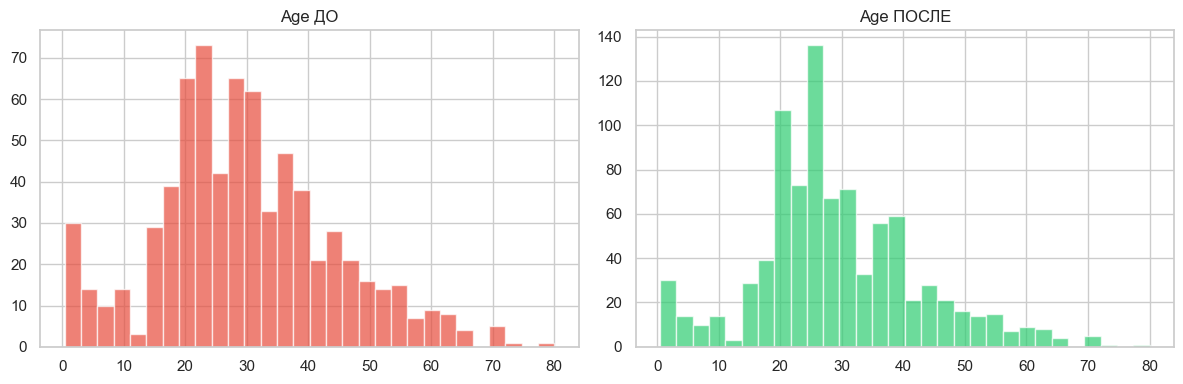

После обработки пропусков 
accuracy = 0.6970

Increase: +-0.0000


In [303]:
train_proc, test_proc = prepare_base(train, test, age_strategy='median_group')

# Проверяем — пропусков не должно остаться в числовых
info = pd.DataFrame({
    'nulls'   : train_proc.isnull().sum(),
})
print(info)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['Age'].hist(bins=30, ax=axes[0], color='#e74c3c', alpha=0.7)
axes[0].set_title('Age ДО')
train_proc['Age'].hist(bins=30, ax=axes[1], color='#2ecc71', alpha=0.7)
axes[1].set_title('Age ПОСЛЕ')
plt.tight_layout()
plt.show()

X_after_missing = train_proc[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
scores['after_missing'] = score(X_after_missing, y, 'После обработки пропусков')
print(f'Increase: +{scores["after_missing"] - scores["baseline"]:.4f}')

## Нормализация


In [304]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

X_num = train_proc[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]

get_score(X_num, y, 'Без нормализации')

for name, scaler in [
    ('StandardScaler (z-score)', StandardScaler()),
    ('MinMaxScaler (0-1)',        MinMaxScaler()),
    ('RobustScaler (медиана)',    RobustScaler()),
]:
    X_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=X_num.columns)
    score(X_scaled, y, name)

Без нормализации 
accuracy = 0.6970

StandardScaler (z-score) 
accuracy = 0.6958

MinMaxScaler (0-1) 
accuracy = 0.7059

RobustScaler (медиана) 
accuracy = 0.6981



In [305]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=X_num.columns)

scaler_final = StandardScaler()
X_scaled_final = pd.DataFrame(
    scaler_final.fit_transform(X_num), columns=X_num.columns
)
scores['after_scaling'] = get_score(X_scaled_final, y, 'StandardScaler')
print(f'Increase: +{scores["after_scaling"] - scores["after_missing"]:.4f}')

StandardScaler 
accuracy = 0.6958

Increase: +-0.0011


## Константные и скоррелированные признаки

In [306]:
print('=== Константные признаки ===')
const_cols = [c for c in train_proc.columns if train_proc[c].nunique() <= 1]
print(f'Найдено: {const_cols if const_cols else "нет"}')
print()

print('=== Почти константные (>95% одного значения) ===')
quasi_const = []
for col in train_proc.select_dtypes(include=[np.number]).columns:
    top_freq = train_proc[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        quasi_const.append((col, f'{top_freq:.1%}'))
print(quasi_const if quasi_const else 'нет')

=== Константные признаки ===
Найдено: нет

=== Почти константные (>95% одного значения) ===
нет


## FamilySize

In [307]:
train_proc['FamilySize'] = train_proc['SibSp'] + train_proc['Parch'] + 1
test_proc['FamilySize']  = test_proc['SibSp']  + test_proc['Parch']  + 1

scaler_tmp = StandardScaler()

print('--- SibSp + Parch отдельно ---')
X_with_both = train_proc[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
score(pd.DataFrame(scaler_tmp.fit_transform(X_with_both), columns=X_with_both.columns), y)

print()
print('--- FamilySize вместо SibSp и Parch ---')
X_family = train_proc[['Pclass', 'Age', 'FamilySize', 'Fare']]
score(pd.DataFrame(scaler_tmp.fit_transform(X_family), columns=X_family.columns), y)

print()
print('--- Все три вместе ---')
X_all3 = train_proc[['Pclass', 'Age', 'SibSp', 'Parch', 'FamilySize', 'Fare']]
score(pd.DataFrame(scaler_tmp.fit_transform(X_all3), columns=X_all3.columns), y)

--- SibSp + Parch отдельно ---
 
accuracy = 0.6958


--- FamilySize вместо SibSp и Parch ---
 
accuracy = 0.6947


--- Все три вместе ---
 
accuracy = 0.6958



np.float64(0.6958383026803088)

## Категориальные признаки

In [308]:
from sklearn.preprocessing import LabelEncoder

def extract_title(df_train, df_test):
    """Извлекает Title из Name и группирует редкие значения."""
    tr = df_train.copy()
    te = df_test.copy()

    for df in [tr, te]:
        df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
        df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Редкие титулы определяем ТОЛЬКО по train — чтобы не было утечки
    rare = tr['Title'].value_counts()[tr['Title'].value_counts() < 10].index
    tr['Title'] = tr['Title'].replace(rare, 'Rare')
    te['Title'] = te['Title'].replace(rare, 'Rare')

    return tr, te


def add_categorical_features(df_train, df_test, encoding):
    """Кодирует категориальные признаки: Sex и Title."""
    tr = df_train.copy()
    te = df_test.copy()

    cat_cols = ['Sex', 'Title']

    if encoding == 'label':
        for col in cat_cols:
            le = LabelEncoder()
            le.fit(pd.concat([tr[col], te[col]], axis=0).astype(str))
            tr[col] = le.transform(tr[col].astype(str))
            te[col] = le.transform(te[col].astype(str))

    elif encoding == 'onehot':
        combined = pd.concat([tr[cat_cols], te[cat_cols]], axis=0)
        combined_enc = pd.get_dummies(combined, columns=cat_cols)
        tr_enc = combined_enc.iloc[:len(tr)].reset_index(drop=True)
        te_enc = combined_enc.iloc[len(tr):].reset_index(drop=True)
        tr = pd.concat([tr.drop(cat_cols, axis=1).reset_index(drop=True), tr_enc], axis=1)
        te = pd.concat([te.drop(cat_cols, axis=1).reset_index(drop=True), te_enc], axis=1)

    return tr, te


num_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'FamilySize', 'Fare']

print('--- Только числовые (без категориальных) ---')
X_num_only = train_proc[['Pclass', 'Age', 'SibSp', 'Parch', 'FamilySize', 'Fare']]
sc = StandardScaler()
scores['num_only'] = score(
    pd.DataFrame(sc.fit_transform(X_num_only), columns=X_num_only.columns), y,
    'Только числовые'
)

train_titled, test_titled = extract_title(train_proc, test_proc)
print()
print('--- Label Encoding ---')
tr_le, te_le = add_categorical_features(train_titled, test_titled, encoding='label')
feat_le = [c for c in tr_le.columns if c not in
           ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin', 'Cabin', 'Embarked']]
X_le = tr_le[feat_le]
sc_le = StandardScaler()
scores['label_enc'] = score(
    pd.DataFrame(sc_le.fit_transform(X_le), columns=X_le.columns), y,
    'Label Encoding'
)

print()
print('--- One-Hot Encoding ---')
tr_ohe, te_ohe = add_categorical_features(train_titled, test_titled, encoding='onehot')
feat_ohe = [c for c in tr_ohe.columns if c not in
            ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin', 'Cabin', 'Embarked']]
X_ohe = tr_ohe[feat_ohe]
sc_ohe = StandardScaler()
scores['onehot_enc'] = score(
    pd.DataFrame(sc_ohe.fit_transform(X_ohe), columns=X_ohe.columns), y,
    'One-Hot Encoding'
)

--- Только числовые (без категориальных) ---
Только числовые 
accuracy = 0.6958


--- Label Encoding ---
Label Encoding 
accuracy = 0.8103


--- One-Hot Encoding ---
One-Hot Encoding 
accuracy = 0.8272



In [309]:
# Смотрим что за признаки получились после OHE
print(f'Признаков после OHE: {X_ohe.shape[1]}')
print('Список:')
print(X_ohe.columns.tolist())

Признаков после OHE: 14
Список:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Sex_female', 'Sex_male', 'Title_Dona', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [310]:
tr_ohe.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Sex_female,Sex_male,Title_Dona,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,2,False,True,False,False,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,2,True,False,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,True,False,False,False,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,2,True,False,False,False,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,1,False,True,False,False,False,True,False,False


In [311]:
# Смотрим что за признаки получились после Label
X_le.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Title
0,3,1,22.0,1,0,7.2500,2,3
1,1,0,38.0,1,0,71.2833,2,4
2,3,0,26.0,0,0,7.9250,1,2
3,1,0,35.0,1,0,53.1000,2,4
4,3,1,35.0,0,0,8.0500,1,3


## Convert String values into Numeric

In [312]:
train['Embarked'].replace(['S','C','Q'],[0,1,2],inplace=True)
test['Embarked'].replace(['S','C','Q'],[0,1,2],inplace=True)

0      2
1      0
2      2
3      0
4      0
      ..
413    0
414    1
415    0
416    0
417    1
Name: Embarked, Length: 418, dtype: object

## Dropping UnNeeded Features

In [313]:
#train.drop(['Name','Age','Ticket','Fare','Cabin','PassengerId'],axis=1,inplace=True)
#test.drop(['Name','Age','Ticket','Fare','Cabin','PassengerId'],axis=1,inplace=True)

In [314]:
print(f"Train columns: {train.columns.tolist()}\n")
train.head()

Train columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Final

In [331]:
def full_preprocessing(df_train, df_test):
    """
    Финальный препроцессинг — объединяет все шаги выше.
    Возвращает X_train, X_test, y_train, feature_names.
    """
    tr = df_train.copy()
    te = df_test.copy()
    y  = tr.pop('Survived') 

    # --- Пропуски ---
    # Age: медиана по Pclass+Sex
    group_median = tr.groupby(['Pclass', 'Sex'])['Age'].median()
    for df in [tr, te]:
        df['Age'] = df.apply(
            lambda r: group_median[r['Pclass'], r['Sex']] if pd.isna(r['Age']) else r['Age'],
            axis=1
        )

    # Embarked: мода
    embarked_mode = tr['Embarked'].mode()[0]
    for df in [tr, te]:
        df['Embarked'] = df['Embarked'].fillna(embarked_mode)

    # Fare=0 и пропуски: медиана по классу
    fare_medians = tr.groupby('Pclass')['Fare'].median()
    for df in [tr, te]:
        mask_zero = df['Fare'] == 0
        df.loc[mask_zero, 'Fare'] = df.loc[mask_zero, 'Pclass'].map(fare_medians)
        df['Fare'] = df['Fare'].fillna(df['Pclass'].map(fare_medians))

    # --- Feature Engineering ---
    for df in [tr, te]:
        # Числовые
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        
        # Title
        df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
        rare = tr['Title'].value_counts()[tr['Title'].value_counts() < 10].index
        df['Title'] = df['Title'].replace(rare, 'Rare')
        df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    tr['Deck'] = tr['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
    te['Deck'] = te['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
    train_decks = tr.groupby(['Deck', 'Pclass']).size().unstack(fill_value=0)
    test_decks = te.groupby(['Deck', 'Pclass']).size().unstack(fill_value=0)

    # Label Encoding
    cat_cols = ['Sex', 'Title', 'Deck']
    for col in cat_cols:
            le = LabelEncoder()
            le.fit(pd.concat([tr[col], te[col]], axis=0).astype(str))
            tr[col] = le.transform(tr[col].astype(str))
            te[col] = le.transform(te[col].astype(str))

    tr['Embarked'] = tr['Embarked'].replace(['S','C','Q'],[0,1,2])
    te['Embarked'] = te['Embarked'].replace(['S','C','Q'],[0,1,2])

    
    drop_cols = ['Name', 'Ticket', 'Fare', 'Cabin', 'PassengerId']
    
    tr.drop([col for col in drop_cols], axis=1, inplace=True)
    te.drop([col for col in drop_cols if col != 'Survived'], axis=1, inplace=True)

    return tr, te, y


X_train_final, X_test_final, y_train = full_preprocessing(train, test)

print('Финальная форма X_train:', X_train_final.shape)
print('Финальная форма X_test: ', X_test_final.shape)
print()
print('Признаки:')
print(X_train_final.columns.tolist())
print(X_train_final.head())
print()
print('Пропуски в финальном X_train:')
print(X_train_final.isnull().sum()[X_train_final.isnull().sum() > 0])

Финальная форма X_train: (891, 9)
Финальная форма X_test:  (418, 9)

Признаки:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked', 'Deck', 'FamilySize', 'Title']
   Pclass  Sex   Age  SibSp  Parch Embarked  Deck  FamilySize  Title
0       3    1  22.0      1      0        0     7           2      5
1       1    0  38.0      1      0        1     2           2      6
2       3    0  26.0      0      0        0     7           1      4
3       1    0  35.0      1      0        0     2           2      6
4       3    1  35.0      0      0        0     7           1      5

Пропуски в финальном X_train:
Series([], dtype: int64)


In [352]:
from sklearn.preprocessing import LabelEncoder

# Кодируем Deck в числа
le = LabelEncoder()
train['Deck'] = train['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
train_decks = train.groupby(['Deck', 'Pclass']).size().unstack(fill_value=0)
    
train['Deck_encoded'] = le.fit_transform(train['Deck'])

# Корреляция с числовыми признаками
numeric_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']
corr_deck = train[numeric_cols + ['Deck_encoded']].corr()['Deck_encoded'].sort_values(ascending=False)
print("Корреляция Deck с числовыми:")
print(corr_deck)

train.head()

Корреляция Deck с числовыми:
Deck_encoded    1.000000
Pclass          0.742093
SibSp           0.041058
Parch          -0.031553
Age            -0.267161
Survived       -0.295113
Fare           -0.525742
Name: Deck_encoded, dtype: float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Deck_encoded
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,M,7
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,M,7
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,M,7


In [332]:
scaler_final = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_train_final),
    columns=X_train_final.columns
)
scores['final'] = get_score(X_train_scaled, y_train, 'ФИНАЛЬНЫЙ препроцессинг LE (LogReg)')

ФИНАЛЬНЫЙ препроцессинг LE (LogReg) 
accuracy = 0.7991



In [333]:
X_train_final.to_csv('X_train_preprocessed_le.csv', index=False)
X_test_final.to_csv('X_test_preprocessed_le.csv', index=False)
y_train.to_csv('y_train.csv', index=False)

In [334]:
from sklearn.preprocessing import OneHotEncoder

def full_preprocessing(df_train, df_test):
    """
    Финальный препроцессинг — объединяет все шаги выше.
    Возвращает X_train, X_test, y_train, feature_names.
    """
    tr = df_train.copy()
    te = df_test.copy()
    y  = tr.pop('Survived')

    # --- Пропуски ---
    # Age: медиана по Pclass+Sex
    group_median = tr.groupby(['Pclass', 'Sex'])['Age'].median()
    for df in [tr, te]:
        df['Age'] = df.apply(
            lambda r: group_median[r['Pclass'], r['Sex']] if pd.isna(r['Age']) else r['Age'],
            axis=1
        )

    # Embarked: мода
    embarked_mode = tr['Embarked'].mode()[0]
    for df in [tr, te]:
        df['Embarked'] = df['Embarked'].fillna(embarked_mode)

    # Fare=0 и пропуски: медиана по классу
    fare_medians = tr.groupby('Pclass')['Fare'].median()
    for df in [tr, te]:
        mask_zero = df['Fare'] == 0
        df.loc[mask_zero, 'Fare'] = df.loc[mask_zero, 'Pclass'].map(fare_medians)
        df['Fare'] = df['Fare'].fillna(df['Pclass'].map(fare_medians))

    # --- Feature Engineering ---
    for df in [tr, te]:
        # Числовые
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        
        # Title
        df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
        df['Title'] = df['Title'].fillna('Unknown')
        rare = tr['Title'].value_counts()[tr['Title'].value_counts() < 10].index
        df['Title'] = df['Title'].replace(rare, 'Rare')
        df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    tr['Embarked'] = tr['Embarked'].replace(['S','C','Q'],[0,1,2])
    te['Embarked'] = te['Embarked'].replace(['S','C','Q'],[0,1,2])
    # --- One hot encoding ---
    tr['Deck'] = tr['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
    te['Deck'] = te['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
    train_decks = tr.groupby(['Deck', 'Pclass']).size().unstack(fill_value=0)
    test_decks = te.groupby(['Deck', 'Pclass']).size().unstack(fill_value=0)
    
    cat_cols = ['Sex', 'Title', 'Deck']
    OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(tr[cat_cols]))
    OH_cols_test = pd.DataFrame(OH_encoder.transform(te[cat_cols]))

    OH_cols_train.columns = OH_encoder.get_feature_names_out(cat_cols)
    OH_cols_test.columns = OH_encoder.get_feature_names_out(cat_cols)
 
    num_cols = ['Pclass', 'Age', 'FamilySize', 'SibSp', 'Parch', 'Embarked']
    num_X_train = tr[num_cols].copy()
    num_X_test = te[num_cols].copy()

    tr = pd.concat([num_X_train.reset_index(drop=True), OH_cols_train.reset_index(drop=True)], axis=1)
    te = pd.concat([num_X_test.reset_index(drop=True), OH_cols_test.reset_index(drop=True)], axis=1)

    return tr, te, y
    


X_train_final, X_test_final, y_train = full_preprocessing(train, test)

print('Финальная форма X_train:', X_train_final.shape)
print('Финальная форма X_test: ', X_test_final.shape)
print()
print('Признаки:')
print(X_train_final.columns.tolist())
print(X_train_final.head())
print()
print('Пропуски в финальном X_train:')
print(X_train_final.isnull().sum()[X_train_final.isnull().sum() > 0])

Финальная форма X_train: (891, 22)
Финальная форма X_test:  (418, 22)

Признаки:
['Pclass', 'Age', 'FamilySize', 'SibSp', 'Parch', 'Embarked', 'Sex_female', 'Sex_male', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_M', 'Deck_T']
   Pclass   Age  FamilySize  SibSp  Parch Embarked  Sex_female  Sex_male  \
0       3  22.0           2      1      0        0         0.0       1.0   
1       1  38.0           2      1      0        1         1.0       0.0   
2       3  26.0           1      0      0        0         1.0       0.0   
3       1  35.0           2      1      0        0         1.0       0.0   
4       3  35.0           1      0      0        0         0.0       1.0   

   Title_Master  Title_Miss  ...  Title_Rare  Deck_A  Deck_B  Deck_C  Deck_D  \
0           0.0         0.0  ...         0.0     0.0     0.0     0.0     0.0   
1           0.0         0.0  ...         0.0     0.0   

In [335]:
scaler_final = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_train_final),
    columns=X_train_final.columns
)
scores['final'] = get_score(X_train_scaled, y_train, 'ФИНАЛЬНЫЙ препроцессинг OHE (LogReg)')

ФИНАЛЬНЫЙ препроцессинг OHE (LogReg) 
accuracy = 0.8328



In [336]:
X_train_final.to_csv('X_train_preprocessed_ohe.csv', index=False)
X_test_final.to_csv('X_test_preprocessed_ohe.csv', index=False)
y_train.to_csv('y_train.csv', index=False)